# Alternating surface mass balance as a source of steep isochrones

The ALHIC1901 inverse fit requires an initially ordered wrinkle with approximately 10.3 m amplitude, 15.5 m horizontal wavelength, and an 85° maximum dip. This notebook tests whether alternating bands of accumulation and ablation can create that geometry before background shear folds it.

The central result is qualified. Present Allan Hills surface-mass-balance rates can make a substantial ordered seed, but no tested case reproduces all three target scales at once. The most favorable present-rate cases make 12–14 m-amplitude wrinkles with 66–69° limbs at 60 m wavelength. Such a limb is steep enough for the basal shear used in the fold model to overturn it in about 2–3 kyr. However, 15.5 m surface forcing penetrates only a few meters, and stronger forcing commonly exposes or truncates the layer before making the required smooth seed.

## Observational scales and model target

Stake measurements at Allan Hills give blue-ice ablation rates from 0.009 to 0.046 m yr$^{-1}$ and horizontal speeds below 0.1 m yr$^{-1}$. They also show a spatially complex pattern of accumulation and ablation associated with variable surface winds ([Spaulding et al., 2012](https://doi.org/10.3189/2012JoG11J176)). Independent measurements place Allan Hills sublimation near 0.03–0.05 m yr$^{-1}$ ([Dadic et al., 2013](https://doi.org/10.1002/jgrf.20098)). Elsewhere in East Antarctica, persistent wind scour has removed 16–18 m of firn at about 0.054 m water equivalent per year ([Lenaerts et al., 2015](https://doi.org/10.1002/2015GL065544)).

I therefore sweep mass-balance amplitudes from 0.01 to 0.05 m yr$^{-1}$ as the present-rate range and 0.10 to 0.30 m yr$^{-1}$ as deliberately aggressive windy end members. The latter are not an inferred Little Ice Age reconstruction. They test whether increasing wind-driven ablation changes the mechanical conclusion. The background speed is 0.014 m yr$^{-1}$, matching the 160 m-thick slab used in the ALHIC1901 fit and lying within the observed slow-flow regime.

## Two-dimensional Stokes response

Let $x$ be horizontal distance and $y$ be depth below a flat surface. The imposed surface mass balance is

$$a(x,t)=b\sin[k(x-ct)],$$

where positive $a$ is accumulation, $b$ is the mass-balance amplitude, $k=2\pi/\lambda$ is wavenumber, and $c$ is band-migration speed. For a fixed flat surface, the downward ice velocity at $y=0$ equals $a$. The streamfunction

$$\psi=Uy+\frac{b}{k}(1+ky)e^{-ky}\cos[k(x-ct)]$$

is biharmonic and therefore gives an exact incompressible, linear-viscous two-dimensional Stokes solution in a half-space. The velocities are

$$u=U-bky e^{-ky}\cos[k(x-ct)],\qquad v=b(1+ky)e^{-ky}\sin[k(x-ct)],$$

with $v$ positive downward. The perturbation decays over $k^{-1}=\lambda/(2\pi)$. This is a kinematic Dirichlet end member: it imposes the surface-normal velocity needed to maintain a flat surface rather than solving a free surface or atmospheric flow.

Initially horizontal material layers are integrated through this velocity. A layer is called *ordered* when every marker remains below the surface and the final mapping from initial to final horizontal position remains positive. The calculation records layer amplitude, maximum dip, exposure, and the time required for later simple shear to rotate the adverse limb through vertical.

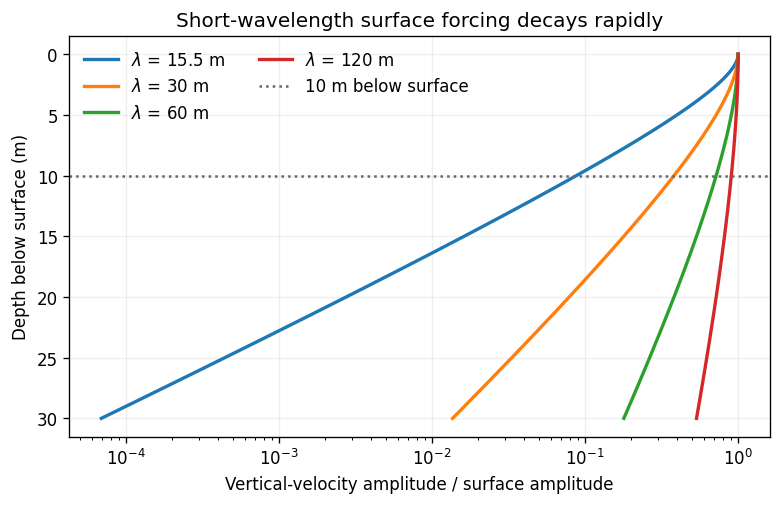

The target wavelength has an e-folding depth of **2.47 m**. At 149 m below the surface, the response is only **3.6e-25** of its surface value. Alternating surface mass balance therefore cannot directly deform the present basal target at this wavelength.

In [1]:
import itertools
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore", message="IProgress not found.*")
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})

U = 0.014                         # background ice speed, m yr^-1
BASAL_SHEAR = 1.727e-4            # yr^-1, from the 160 m full-Stokes slab
TARGET_WAVELENGTH = 15.5          # m
TARGET_AMPLITUDE = 10.3           # m
TARGET_DIP = 85.0                 # degrees
INITIAL_DEPTHS = np.array([2.0, 5.0, 10.0, 20.0])  # m below surface
OUTPUT_TIMES = (200.0, 500.0, 1000.0)              # yr

def attenuation(depth, wavelength):
    kd = 2 * np.pi * np.asarray(depth) / wavelength
    return (1 + kd) * np.exp(-kd)

depth_axis = np.linspace(0.0, 30.0, 400)
fig, ax = plt.subplots(figsize=(6.4, 4.1), constrained_layout=True)
for wavelength in [15.5, 30.0, 60.0, 120.0]:
    ax.semilogx(attenuation(depth_axis, wavelength), depth_axis, lw=2,
                label=f"$\lambda$ = {wavelength:g} m")
ax.axhline(10.0, color="0.4", ls=":", label="10 m below surface")
ax.invert_yaxis()
ax.set(xlabel="Vertical-velocity amplitude / surface amplitude",
       ylabel="Depth below surface (m)",
       title="Short-wavelength surface forcing decays rapidly")
ax.legend(frameon=False, ncol=2)
plt.show()

target_penetration = 1 / (2 * np.pi / TARGET_WAVELENGTH)
basal_attenuation = attenuation(149.0, TARGET_WAVELENGTH)
display(Markdown(
    f"The target wavelength has an e-folding depth of **{target_penetration:.2f} m**. "
    f"At 149 m below the surface, the response is only **{basal_attenuation:.1e}** of its "
    f"surface value. Alternating surface mass balance therefore cannot directly deform the "
    f"present basal target at this wavelength."
))

In [2]:
def stokes_velocity(pattern_x, depth, rate, wavelength, migration_speed):
    depth = np.maximum(np.asarray(depth), 0.0)
    k = 2 * np.pi / wavelength
    decay = np.exp(-k * depth)
    phase = k * pattern_x
    horizontal = U - migration_speed - rate * k * depth * decay * np.cos(phase)
    downward = rate * (1 + k * depth) * decay * np.sin(phase)
    return horizontal, downward

def layer_metrics(initial_x, pattern_x, depth, active, initial_depth):
    metrics = {
        "initial_depth": float(initial_depth),
        "surviving_fraction": float(np.mean(active)),
        "amplitude": np.nan, "dip": np.nan,
        "minimum_mapping": np.nan, "ordered": False,
    }
    if np.all(active):
        dx_dX = np.gradient(pattern_x, initial_x)
        dy_dX = np.gradient(depth, initial_x)
        minimum_mapping = float(np.min(dx_dX))
        metrics.update(
            amplitude=float(0.5 * np.ptp(depth)),
            dip=float(np.degrees(np.arctan(np.max(np.abs(dy_dX / dx_dX))))),
            minimum_mapping=minimum_mapping,
            ordered=minimum_mapping > 0.0,
        )
    return metrics

def simulate_history(rate, wavelength, speed_ratio, output_times=OUTPUT_TIMES,
                     depths=INITIAL_DEPTHS, nx=81, dt=2.0, return_states=False):
    initial_x = np.linspace(0.0, wavelength, nx)
    pattern_x = np.broadcast_to(initial_x, (len(depths), nx)).copy()
    depth = np.broadcast_to(np.asarray(depths)[:, None], pattern_x.shape).copy()
    active = np.ones_like(depth, dtype=bool)
    migration_speed = speed_ratio * U
    output_steps = {int(round(time / dt)): time for time in output_times}
    metrics, states = {}, {}

    for step in range(1, max(output_steps) + 1):
        k1x, k1y = stokes_velocity(pattern_x, depth, rate, wavelength, migration_speed)
        k2x, k2y = stokes_velocity(
            pattern_x + 0.5 * dt * k1x, depth + 0.5 * dt * k1y,
            rate, wavelength, migration_speed,
        )
        k3x, k3y = stokes_velocity(
            pattern_x + 0.5 * dt * k2x, depth + 0.5 * dt * k2y,
            rate, wavelength, migration_speed,
        )
        k4x, k4y = stokes_velocity(
            pattern_x + dt * k3x, depth + dt * k3y,
            rate, wavelength, migration_speed,
        )
        x_new = pattern_x + dt * (k1x + 2 * k2x + 2 * k3x + k4x) / 6
        depth_new = depth + dt * (k1y + 2 * k2y + 2 * k3y + k4y) / 6
        newly_exposed = active & (depth_new <= 0.0)
        active[newly_exposed] = False
        pattern_x = np.where(active, x_new, pattern_x)
        depth = np.where(active, depth_new, 0.0)

        if step in output_steps:
            time = output_steps[step]
            metrics[time] = [
                layer_metrics(initial_x, pattern_x[j], depth[j], active[j], initial_depth)
                for j, initial_depth in enumerate(depths)
            ]
            if return_states:
                states[time] = {
                    "initial_x": initial_x.copy(), "pattern_x": pattern_x.copy(),
                    "depth": depth.copy(), "active": active.copy(),
                }
    return metrics, states

def seed_score(record):
    if not record["ordered"]:
        return 0.0
    return min(record["amplitude"] / TARGET_AMPLITUDE, 1.0) * min(record["dip"] / TARGET_DIP, 1.0)

## Parameter sweep

The sweep contains six mass-balance amplitudes, four wavelengths, nine migration speeds, three durations, and four initial layer depths: 2592 layer outcomes. Band speeds range from $-0.5U$ to $1.5U$; $c\approx U$ keeps ice beneath the same mass-balance phase. A relaxed acceptance box requires at least 8 m amplitude and 80° dip while the layer remains continuous and ordered. This is slightly less restrictive than the fitted 10.3 m and 85° target.

In [3]:
rates = np.array([0.01, 0.03, 0.05, 0.10, 0.20, 0.30])
wavelengths = np.array([15.5, 30.0, 60.0, 120.0])
speed_ratios = np.array([-0.5, 0.0, 0.5, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5])
records = []
for rate, wavelength, speed_ratio in itertools.product(rates, wavelengths, speed_ratios):
    history, _ = simulate_history(rate, wavelength, speed_ratio)
    for time, layers in history.items():
        for layer in layers:
            record = {
                "rate": float(rate), "wavelength": float(wavelength),
                "speed_ratio": float(speed_ratio), "time": float(time), **layer,
            }
            record["score"] = seed_score(record)
            records.append(record)

ordered_records = [record for record in records if record["ordered"]]
acceptance_cases = [
    record for record in ordered_records
    if record["amplitude"] >= 8.0 and record["dip"] >= 80.0
]
best_present = max(
    (record for record in ordered_records if record["rate"] <= 0.05),
    key=lambda record: record["score"],
)
best_target_spacing = max(
    (record for record in ordered_records if record["rate"] <= 0.05
     and record["wavelength"] == TARGET_WAVELENGTH),
    key=lambda record: record["score"],
)
best_windy = max(
    (record for record in ordered_records if record["rate"] >= 0.10),
    key=lambda record: record["score"],
)
exposed_count = sum(record["surviving_fraction"] < 1.0 for record in records)
overturned_count = len(records) - len(ordered_records) - exposed_count

def compact_case(record):
    return (
        f"$b={record['rate']:.2f}$ m yr$^{{-1}}$, $\lambda={record['wavelength']:.1f}$ m, "
        f"$c/U={record['speed_ratio']:.1f}$, $T={record['time']:.0f}$ yr, "
        f"$y_0={record['initial_depth']:.0f}$ m: amplitude {record['amplitude']:.1f} m, "
        f"dip {record['dip']:.1f}°"
    )

display(Markdown(
    f"The sweep produced **{len(ordered_records)} ordered outcomes** and "
    f"**{exposed_count} exposed or truncated outcomes**, and **{overturned_count} smooth but "
    f"already overturned outcomes**. Exactly **{len(acceptance_cases)}** "
    f"ordered cases enter the relaxed 8 m, 80° acceptance box. The best present-rate "
    f"case is {compact_case(best_present)}. At the fitted wavelength, the best present-rate "
    f"case is {compact_case(best_target_spacing)}."
))

The sweep produced **772 ordered outcomes** and **1815 exposed or truncated outcomes**, and **5 smooth but already overturned outcomes**. Exactly **0** ordered cases enter the relaxed 8 m, 80° acceptance box. The best present-rate case is $b=0.03$ m yr$^{-1}$, $\lambda=60.0$ m, $c/U=1.2$, $T=1000$ yr, $y_0=20$ m: amplitude 13.8 m, dip 69.2°. At the fitted wavelength, the best present-rate case is $b=0.03$ m yr$^{-1}$, $\lambda=15.5$ m, $c/U=1.0$, $T=1000$ yr, $y_0=10$ m: amplitude 3.7 m, dip 74.5°.

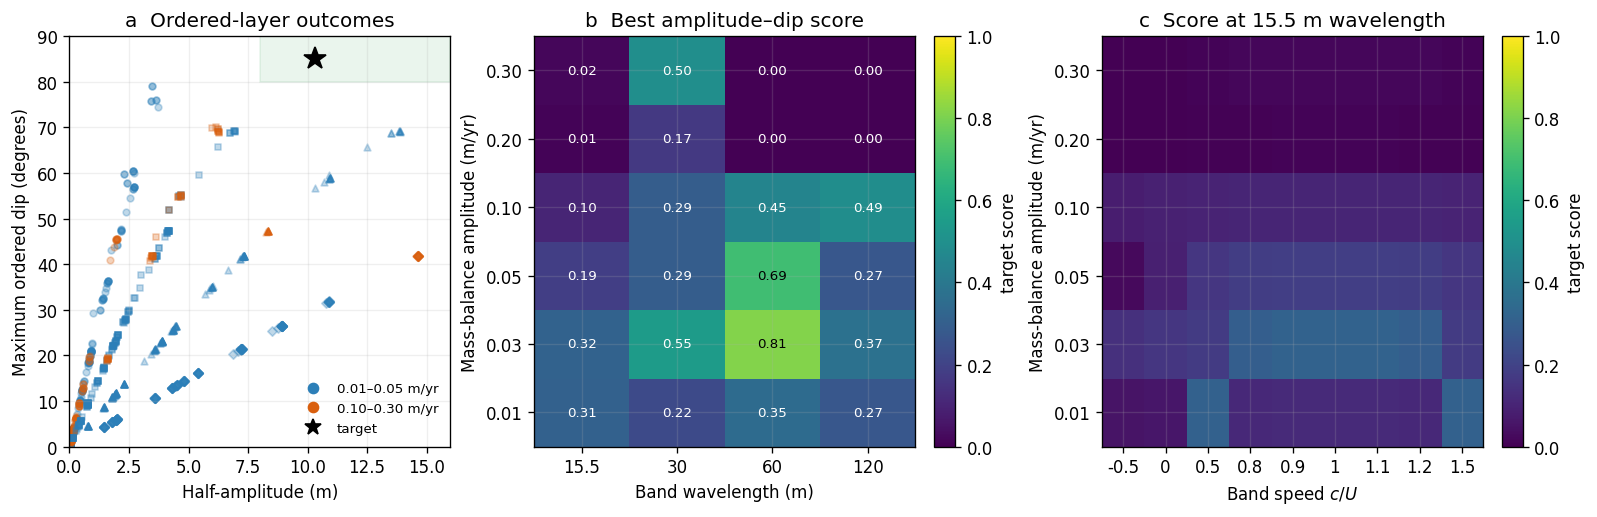

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2), constrained_layout=True)

for wavelength, marker in zip(wavelengths, ["o", "s", "^", "D"]):
    current = [r for r in ordered_records if r["wavelength"] == wavelength and r["rate"] <= 0.05]
    windy = [r for r in ordered_records if r["wavelength"] == wavelength and r["rate"] >= 0.10]
    axes[0].scatter([r["amplitude"] for r in current], [r["dip"] for r in current],
                    s=16, marker=marker, color="#2c7fb8", alpha=0.30)
    axes[0].scatter([r["amplitude"] for r in windy], [r["dip"] for r in windy],
                    s=16, marker=marker, color="#d95f0e", alpha=0.28)
axes[0].add_patch(plt.Rectangle((8.0, 80.0), 8.0, 10.0, color="#31a354", alpha=0.10,
                                label="relaxed acceptance box"))
axes[0].plot(TARGET_AMPLITUDE, TARGET_DIP, marker="*", ms=14, color="black", label="inverse-fit target")
axes[0].set(xlabel="Half-amplitude (m)", ylabel="Maximum ordered dip (degrees)",
            title="a  Ordered-layer outcomes", xlim=(0, 16), ylim=(0, 90))
axes[0].legend(handles=[
    Line2D([], [], marker="o", ls="", color="#2c7fb8", label="0.01–0.05 m/yr"),
    Line2D([], [], marker="o", ls="", color="#d95f0e", label="0.10–0.30 m/yr"),
    Line2D([], [], marker="*", ls="", color="black", markersize=10, label="target"),
], frameon=False, fontsize=8)

best_score = np.zeros((len(rates), len(wavelengths)))
for i, rate in enumerate(rates):
    for j, wavelength in enumerate(wavelengths):
        best_score[i, j] = max(
            r["score"] for r in records
            if r["rate"] == rate and r["wavelength"] == wavelength
        )
image = axes[1].imshow(best_score, origin="lower", aspect="auto", vmin=0, vmax=1, cmap="viridis")
axes[1].set(xticks=np.arange(len(wavelengths)), xticklabels=[f"{w:g}" for w in wavelengths],
            yticks=np.arange(len(rates)), yticklabels=[f"{r:.2f}" for r in rates],
            xlabel="Band wavelength (m)", ylabel="Mass-balance amplitude (m/yr)",
            title="b  Best amplitude–dip score")
for i in range(len(rates)):
    for j in range(len(wavelengths)):
        axes[1].text(j, i, f"{best_score[i, j]:.2f}", ha="center", va="center",
                     color="white" if best_score[i, j] < 0.55 else "black", fontsize=8)
fig.colorbar(image, ax=axes[1], label="target score")

spacing_score = np.zeros((len(rates), len(speed_ratios)))
for i, rate in enumerate(rates):
    for j, speed_ratio in enumerate(speed_ratios):
        spacing_score[i, j] = max(
            r["score"] for r in records
            if r["rate"] == rate and r["wavelength"] == TARGET_WAVELENGTH
            and r["speed_ratio"] == speed_ratio
        )
image2 = axes[2].imshow(spacing_score, origin="lower", aspect="auto", vmin=0, vmax=1, cmap="viridis")
axes[2].set(xticks=np.arange(len(speed_ratios)), xticklabels=[f"{c:g}" for c in speed_ratios],
            yticks=np.arange(len(rates)), yticklabels=[f"{r:.2f}" for r in rates],
            xlabel="Band speed $c/U$", ylabel="Mass-balance amplitude (m/yr)",
            title="c  Score at 15.5 m wavelength")
fig.colorbar(image2, ax=axes[2], label="target score")
plt.show()

The parameter sweep shows a geometric tradeoff. Short bands make steep limbs but have insufficient vertical reach. Long bands make order-10 m relief but remain less steep. Increasing $b$ does not remove this tradeoff because near-surface layers are increasingly exposed in the ablation half-band, leaving only deeper and more weakly forced layers continuous. Band migration near the ice speed modestly increases residence time, but it does not produce the missing combination of amplitude and dip.

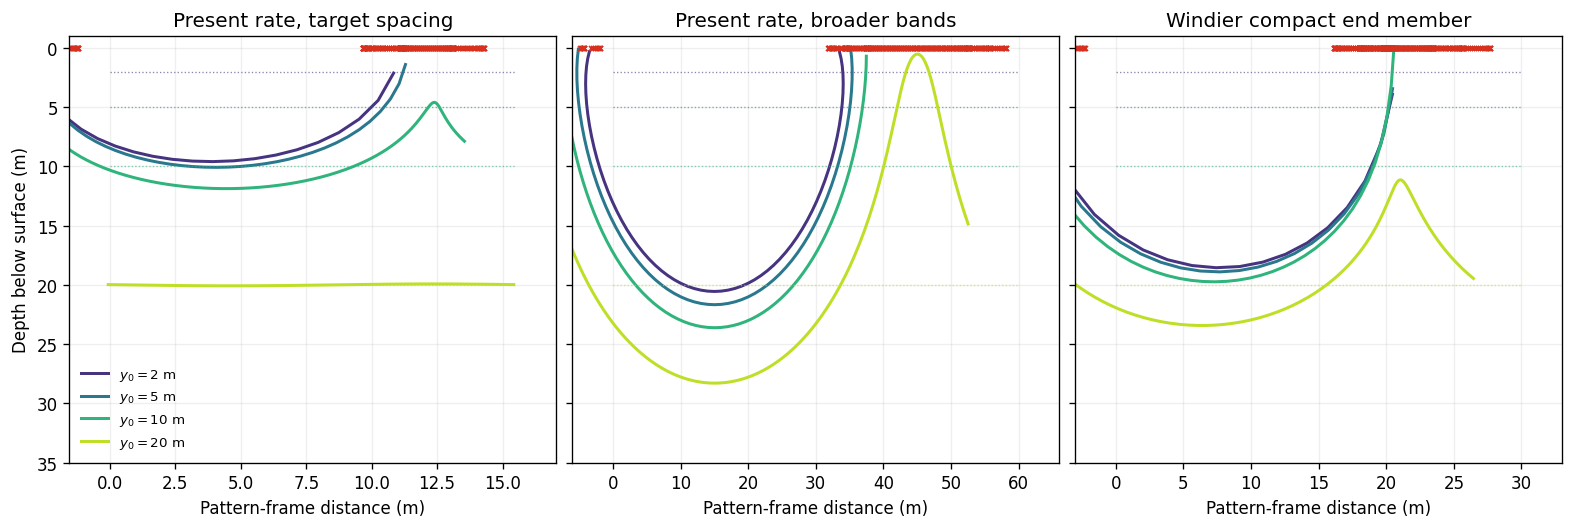

| Case | $b$ (m yr$^{-1}$) | $\lambda$ (m) | $c/U$ | Duration (yr) | Layer depth (m) | Amplitude (m) | Dip | Later fold time (kyr) |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Present rate, target spacing | 0.03 | 15.5 | 1.1 | 1000 | 10 | 3.64 | 75.9° | 1.45 |
| Present rate, broader bands | 0.03 | 60.0 | 1.0 | 1000 | 20 | 13.88 | 69.2° | 2.21 |
| Windier compact end member | 0.30 | 30.0 | 0.0 | 200 | 20 | 6.14 | 70.0° | 2.11 |

In [5]:
case_specs = [
    {"name": "Present rate, target spacing", "rate": 0.03, "wavelength": 15.5,
     "speed_ratio": 1.1, "time": 1000.0, "diagnostic_depth": 10.0},
    {"name": "Present rate, broader bands", "rate": 0.03, "wavelength": 60.0,
     "speed_ratio": 1.0, "time": 1000.0, "diagnostic_depth": 20.0},
    {"name": "Windier compact end member", "rate": 0.30, "wavelength": 30.0,
     "speed_ratio": 0.0, "time": 200.0, "diagnostic_depth": 20.0},
]
representative = []
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.3), constrained_layout=True, sharey=True)
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(INITIAL_DEPTHS)))
for axis, spec in zip(axes, case_specs):
    history, states = simulate_history(
        spec["rate"], spec["wavelength"], spec["speed_ratio"],
        output_times=(spec["time"],), nx=161, dt=1.0, return_states=True,
    )
    state = states[spec["time"]]
    metrics = history[spec["time"]]
    selected = next(row for row in metrics if row["initial_depth"] == spec["diagnostic_depth"])
    representative.append({**spec, **selected})
    for j, (initial_depth, color) in enumerate(zip(INITIAL_DEPTHS, colors)):
        axis.plot(state["initial_x"], np.full_like(state["initial_x"], initial_depth),
                  ls=":", lw=0.8, color=color, alpha=0.6)
        offset = np.mean(state["pattern_x"][j] - state["initial_x"])
        aligned_x = state["pattern_x"][j] - offset
        active = state["active"][j]
        axis.plot(np.ma.masked_where(~active, aligned_x), np.ma.masked_where(~active, state["depth"][j]),
                  lw=1.8, color=color, label=f"$y_0={initial_depth:g}$ m")
        if np.any(~active):
            axis.plot(aligned_x[~active], np.zeros(np.count_nonzero(~active)), "x", color="#d7301f", ms=3)
    axis.set(xlabel="Pattern-frame distance (m)", title=spec["name"],
             xlim=(-0.1 * spec["wavelength"], 1.1 * spec["wavelength"]), ylim=(35, -1))
axes[0].set_ylabel("Depth below surface (m)")
axes[0].legend(frameon=False, fontsize=8)
plt.show()

table = [
    "| Case | $b$ (m yr$^{-1}$) | $\lambda$ (m) | $c/U$ | Duration (yr) | Layer depth (m) | Amplitude (m) | Dip | Later fold time (kyr) |",
    "|---|---:|---:|---:|---:|---:|---:|---:|---:|",
]
for case in representative:
    fold_time = 1 / (BASAL_SHEAR * np.tan(np.radians(case["dip"]))) / 1000
    table.append(
        f"| {case['name']} | {case['rate']:.2f} | {case['wavelength']:.1f} | "
        f"{case['speed_ratio']:.1f} | {case['time']:.0f} | {case['initial_depth']:.0f} | "
        f"{case['amplitude']:.2f} | {case['dip']:.1f}° | {fold_time:.2f} |"
    )
display(Markdown("\n".join(table)))

The dotted lines are initially horizontal layers; colored lines show surviving material after the mass-balance episode. Red crosses mark exposed material and therefore a surface truncation rather than a smooth wrinkle. The fold time applies the finite-strain condition $1+t u_z m=0$ to the adverse limb, using $u_z=1.727\times10^{-4}$ yr$^{-1}$ from the 160 m full-Stokes slab. It is a second-stage diagnostic, not part of the surface-forcing calculation.

In [6]:
convergence_rows = []
for case in case_specs[:2]:
    coarse_history, _ = simulate_history(
        case["rate"], case["wavelength"], case["speed_ratio"],
        output_times=(case["time"],), nx=81, dt=2.0,
    )
    fine_history, _ = simulate_history(
        case["rate"], case["wavelength"], case["speed_ratio"],
        output_times=(case["time"],), nx=161, dt=1.0,
    )
    coarse_layer = next(row for row in coarse_history[case["time"]]
                        if row["initial_depth"] == case["diagnostic_depth"])
    fine_layer = next(row for row in fine_history[case["time"]]
                      if row["initial_depth"] == case["diagnostic_depth"])
    convergence_rows.append((case["name"], coarse_layer, fine_layer))

convergence_table = [
    "| Case | Coarse/fine amplitude (m) | Coarse/fine dip |",
    "|---|---:|---:|",
]
for name, coarse_layer, fine_layer in convergence_rows:
    convergence_table.append(
        f"| {name} | {coarse_layer['amplitude']:.3f}/{fine_layer['amplitude']:.3f} | "
        f"{coarse_layer['dip']:.2f}°/{fine_layer['dip']:.2f}° |"
    )
display(Markdown("\n".join(convergence_table)))

| Case | Coarse/fine amplitude (m) | Coarse/fine dip |
|---|---:|---:|
| Present rate, target spacing | 3.639/3.640 | 75.88°/75.93° |
| Present rate, broader bands | 13.879/13.879 | 69.06°/69.15° |

## Interpretation

Alternating accumulation and ablation can produce a useful Waddington seed. At measured Allan Hills rates, 30–60 m bands persisting for 0.5–1 kyr make several-meter to order-10 m wrinkles with adverse limbs steep enough for later basal shear to overturn. A windier interval is therefore not required for seed formation, although it broadens the range of possible amplitudes.

The calculation does not reproduce the inverse-fit seed literally. No tested ordered layer combines at least 8 m amplitude with at least 80° dip. At 15.5 m wavelength, the best present-rate layer is steep but only about 3.6 m in amplitude. Broader present-rate bands reach the required amplitude but only about 70° dip. Stronger forcing is not monotonically helpful: it exposes shallow layers, producing a scour unconformity, while deeper surviving layers feel an attenuated velocity.

The most restrictive result is depth attenuation. Surface forcing at 15.5 m wavelength cannot directly perturb ice now 149 m below the surface. The seed must have formed when the relevant ice was near the surface and then been transported to its present position, or the observed folds must involve a surface unconformity rather than a smooth material wrinkle. Present Allan Hills emergence flow makes the first history nontrivial.

This mechanism therefore remains viable as the first stage of a composite history: wind-controlled surface mass balance creates a broad steep wrinkle or truncation, later compression shortens its wavelength, and background shear overturns it. Radar evidence for 30–60 m layer relief, a buried blue-ice surface, or later horizontal shortening would distinguish this history from a purely basal seed.